# 02 EDA and Visualization
## EDA 및 시각화

Core EDA figures used in the portfolio note.


## Setup
### 설정


In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid")
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120

candidate_processed_dirs = []
if os.environ.get("XENTE_PROCESSED_DIR"):
    candidate_processed_dirs.append(Path(os.environ["XENTE_PROCESSED_DIR"]))
candidate_processed_dirs.extend([
    Path.cwd().parent / "outputs" / "tables",
    Path.cwd() / "outputs" / "tables",
    Path.cwd().parent / "processed",
    Path.cwd() / "processed",
    Path("/content/drive/MyDrive/XENTE DATA/processed"),
])

PROCESSED_DIR = next(
    (path for path in candidate_processed_dirs if (path / "train_model_table_v1.csv").exists()),
    candidate_processed_dirs[-1],
)
MODEL_TABLE_PATH = PROCESSED_DIR / "train_model_table_v1.csv"
FIGURE_DIR = (
    Path.cwd().parent / "outputs" / "figures"
    if (Path.cwd().parent / "outputs").exists()
    else Path.cwd() / "outputs" / "figures"
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SAVE_FIGS = True


def save_fig(filename):
    if SAVE_FIGS:
        path = FIGURE_DIR / filename
        plt.savefig(path, dpi=180, bbox_inches="tight")


def load_first_existing(paths, label):
    for path in paths:
        path = Path(path)
        if path.exists():
            return pd.read_csv(path)
    return None


def default_rate_table(data, group_col):
    output = (
        data
        .groupby(group_col, observed=False)
        .agg(
            loan_count=("IsDefaulted", "count"),
            default_count=("IsDefaulted", "sum"),
            default_rate=("IsDefaulted", "mean"),
        )
        .reset_index()
    )
    output["default_rate_pct"] = output["default_rate"] * 100
    return output


def label_bar_patches(ax, fmt="{:.1f}%", padding_ratio=0.02, fontsize=9):
    y_min, y_max = ax.get_ylim()
    offset = (y_max - y_min) * padding_ratio
    for patch in ax.patches:
        height = patch.get_height()
        if not np.isfinite(height):
            continue
        x = patch.get_x() + patch.get_width() / 2
        ax.text(x, height + offset, fmt.format(height), ha="center", va="bottom", fontsize=fontsize)


base_color = "#6B8EAD"
highlight_color = "#C87A7E"
retail_color = "#E76F51"
neutral_color = "#8FA6B2"


In [2]:
model_table = pd.read_csv(MODEL_TABLE_PATH)
model_table["IsDefaulted"] = model_table["IsDefaulted"].astype(int)

if "IssuedDateLoan" in model_table.columns:
    model_table["IssuedDateLoan"] = pd.to_datetime(model_table["IssuedDateLoan"], errors="coerce")
if "issue_month" not in model_table.columns and "IssuedDateLoan" in model_table.columns:
    model_table["issue_month"] = model_table["IssuedDateLoan"].dt.month
if "issue_weekday" not in model_table.columns and "IssuedDateLoan" in model_table.columns:
    model_table["issue_weekday"] = model_table["IssuedDateLoan"].dt.day_name()

prior_txn_map = {
    "no_prior_txn": "No prior transaction",
    "low_txn_history": "Low transaction history",
    "medium_txn_history": "Medium transaction history",
    "high_txn_history": "High transaction history",
}
product_map = {
    "airtime": "Airtime",
    "data_bundles": "Data Bundles",
    "financial_services": "Financial Services",
    "movies": "Movies",
    "retail": "Retail",
    "tv": "TV",
    "utility_bill": "Utility Bill",
}
issuer_map = {
    "InvestorId_1": "Loan Issuer 1",
    "InvestorId_2": "Loan Issuer 2",
    "InvestorId_3": "Loan Issuer 3",
}
service_flow_map = {
    "SubscriptionId_1": "Service Flow ID 1",
    "SubscriptionId_4": "Service Flow ID 4",
    "SubscriptionId_5": "Service Flow ID 5",
    "SubscriptionId_6": "Service Flow ID 6",
    "SubscriptionId_7": "Service Flow ID 7",
}

model_table["repayment_group"] = np.where(
    model_table["repayment_history_segment"].eq("cold_start_no_known_repayment"),
    "No prior repayment history",
    "Prior repayment history",
)
model_table["transaction_history_group"] = (
    model_table["prior_txn_segment"].map(prior_txn_map).fillna(model_table["prior_txn_segment"])
)
txn_group_order = [
    "No prior transaction",
    "Low transaction history",
    "Medium transaction history",
    "High transaction history",
]
model_table["transaction_history_group"] = pd.Categorical(
    model_table["transaction_history_group"],
    categories=txn_group_order,
    ordered=True,
)
model_table["product_category_label"] = (
    model_table["ProductCategory"].map(product_map).fillna(model_table["ProductCategory"])
)
model_table["loan_issuer_label"] = (
    model_table["InvestorId"].map(issuer_map).fillna(model_table["InvestorId"])
)
model_table["service_flow_label"] = (
    model_table["SubscriptionId"].map(service_flow_map).fillna(model_table["SubscriptionId"])
)
if "issue_month" in model_table.columns:
    model_table["issue_month_label"] = "Month " + model_table["issue_month"].astype("Int64").astype(str)

cold_start = model_table[
    model_table["repayment_history_segment"].eq("cold_start_no_known_repayment")
].copy()

display(pd.DataFrame([{
    "total_loans": len(model_table),
    "total_defaults": int(model_table["IsDefaulted"].sum()),
    "cold_start_loans": len(cold_start),
    "cold_start_defaults": int(cold_start["IsDefaulted"].sum()),
}]))


,total_loans,total_defaults,cold_start_loans,cold_start_defaults
0,1153,71,385,59


## Repayment history segment
### 상환 이력 그룹


,Repayment History Segment,Loan Count,Default Count,default_rate,Default Rate (%),Share of Defaults (%)
0,No prior repayment history,385,59,0.153247,15.324675,83.098592
1,Prior repayment history,768,12,0.015625,1.562500,16.901408


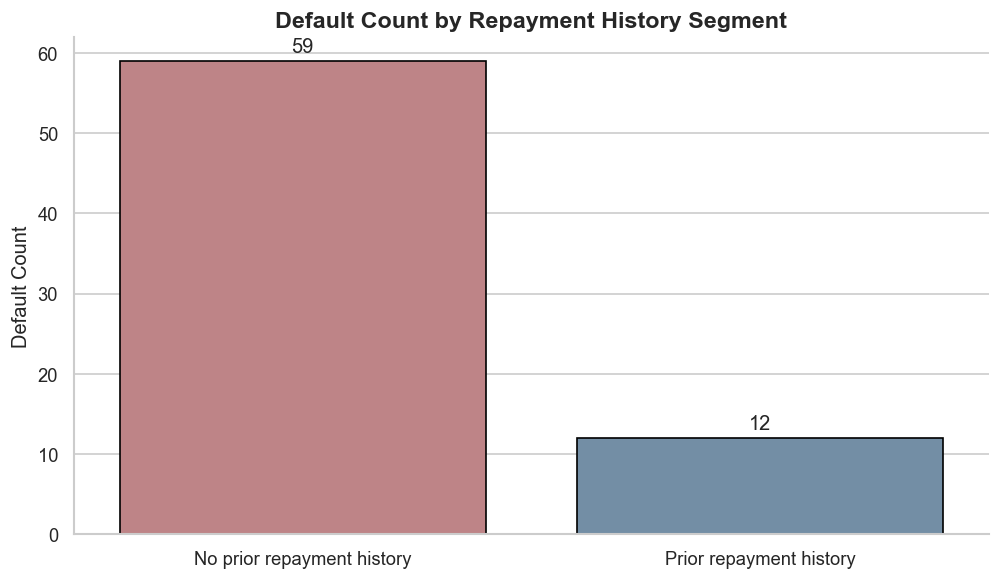

In [3]:
repayment_summary = default_rate_table(model_table, "repayment_group")
repayment_summary["default_share_pct"] = (
    repayment_summary["default_count"] / repayment_summary["default_count"].sum() * 100
)
display(repayment_summary.rename(columns={
    "repayment_group": "Repayment History Segment",
    "loan_count": "Loan Count",
    "default_count": "Default Count",
    "default_rate_pct": "Default Rate (%)",
    "default_share_pct": "Share of Defaults (%)",
}))

fig, ax = plt.subplots(figsize=(8.5, 5.0))
plot_data = repayment_summary.sort_values("default_count", ascending=False)
sns.barplot(
    data=plot_data,
    x="repayment_group",
    y="default_count",
    palette=[highlight_color if "No prior" in x else base_color for x in plot_data["repayment_group"]],
    edgecolor="black",
    linewidth=1,
    ax=ax,
)
ax.set_title("Default Count by Repayment History Segment", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Default Count")
ax.tick_params(axis="x", rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)
sns.despine(left=False, bottom=False)
plt.tight_layout()
save_fig("main_01_default_count_by_repayment_segment.png")
plt.show()


## Transaction history group
### 거래 이력 그룹


,Transaction History Group,Loan Count,Default Count,default_rate,Default Rate (%)
0,No prior transaction,217,53,0.244240,24.423963
1,Low transaction history,20,1,0.050000,5.000000
2,Medium transaction history,64,1,0.015625,1.562500
3,High transaction history,84,4,0.047619,4.761905


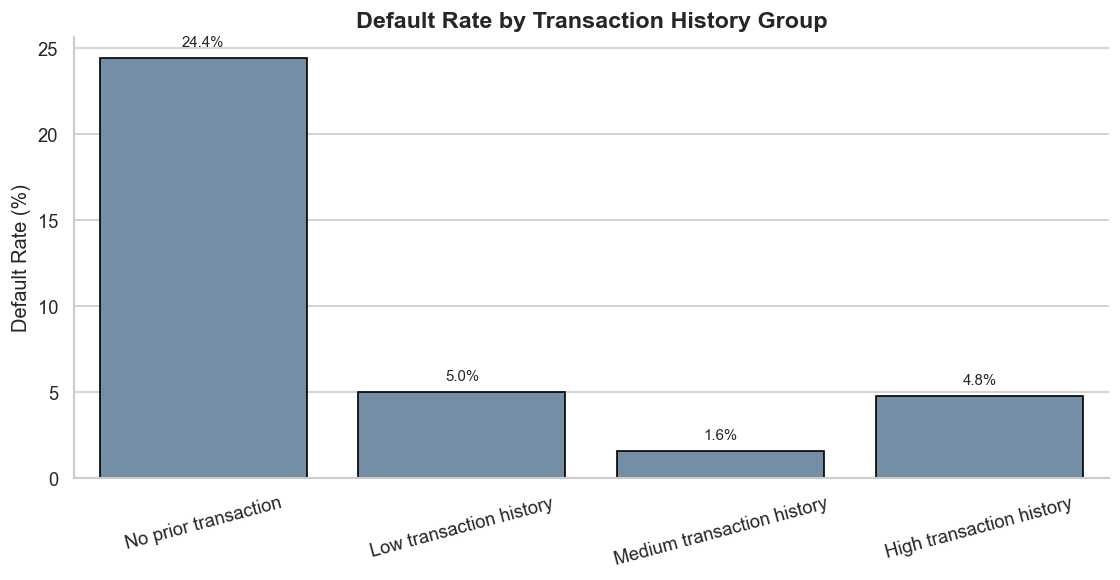

In [4]:
txn_summary = default_rate_table(cold_start, "transaction_history_group")
display(txn_summary.rename(columns={
    "transaction_history_group": "Transaction History Group",
    "loan_count": "Loan Count",
    "default_count": "Default Count",
    "default_rate_pct": "Default Rate (%)",
}))

fig, ax = plt.subplots(figsize=(9.5, 5.0))
sns.barplot(
    data=txn_summary,
    x="transaction_history_group",
    y="default_rate_pct",
    color=base_color,
    edgecolor="black",
    linewidth=1,
    ax=ax,
)
ax.set_title("Default Rate by Transaction History Group", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Default Rate (%)")
ax.tick_params(axis="x", rotation=15)
label_bar_patches(ax)
sns.despine(left=False, bottom=False)
plt.tight_layout()
save_fig("main_02_default_rate_by_transaction_history.png")
plt.show()


## Product category concentration
### 상품군 미상환 집중


,Product Category,Loan Count,Default Count,default_rate,Default Rate (%)
0,Airtime,218,8,0.036697,3.669725
3,Retail,64,50,0.781250,78.125000
1,Data Bundles,57,1,0.017544,1.754386
5,Utility Bill,33,0,0.000000,0.000000
4,TV,11,0,0.000000,0.000000
2,Movies,2,0,0.000000,0.000000


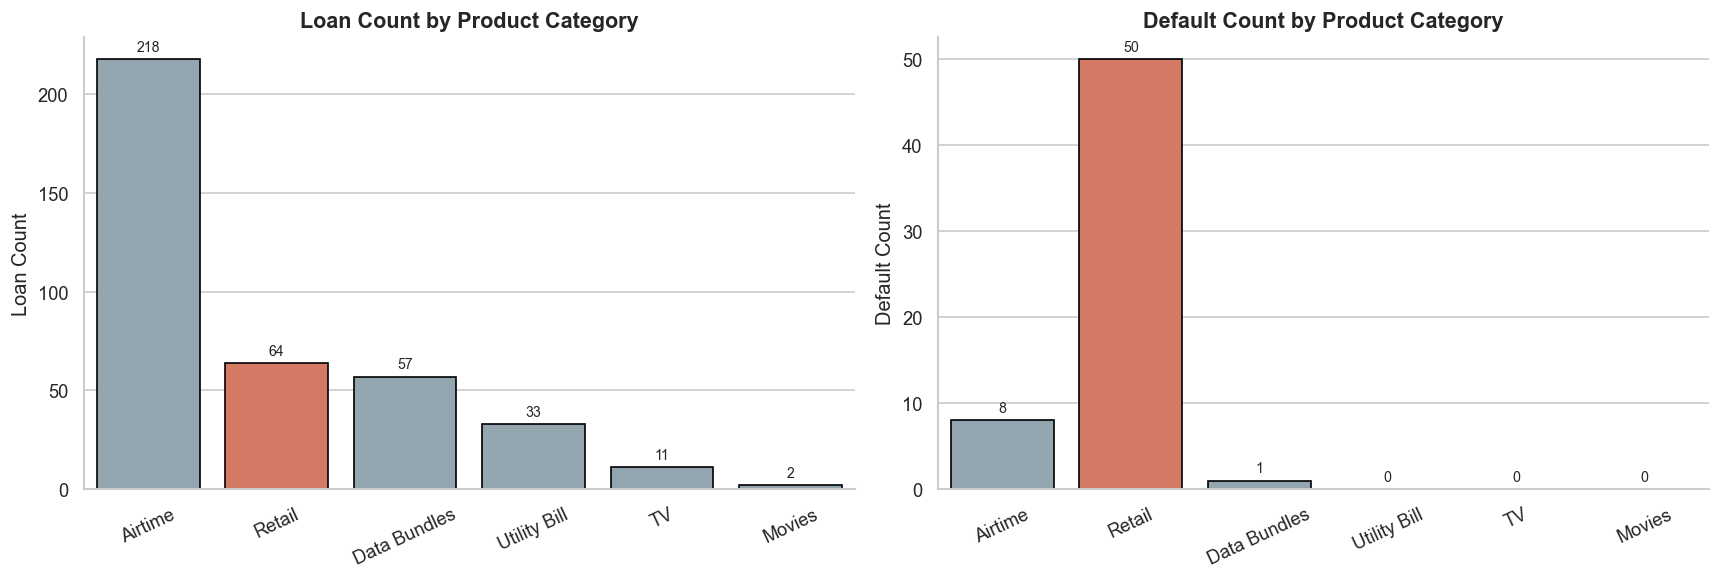

In [5]:
product_summary = default_rate_table(cold_start, "product_category_label")
product_summary = product_summary.sort_values("loan_count", ascending=False)
display(product_summary.rename(columns={
    "product_category_label": "Product Category",
    "loan_count": "Loan Count",
    "default_count": "Default Count",
    "default_rate_pct": "Default Rate (%)",
}))

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.0))
for ax, y_col, title, y_label in [
    (axes[0], "loan_count", "Loan Count by Product Category", "Loan Count"),
    (axes[1], "default_count", "Default Count by Product Category", "Default Count"),
]:
    sns.barplot(
        data=product_summary,
        x="product_category_label",
        y=y_col,
        palette=[retail_color if x == "Retail" else neutral_color for x in product_summary["product_category_label"]],
        edgecolor="black",
        linewidth=1,
        ax=ax,
    )
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(y_label)
    ax.tick_params(axis="x", rotation=25)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f", padding=3, fontsize=8.5)
sns.despine(left=False, bottom=False)
plt.tight_layout()
save_fig("main_03_product_loan_vs_default_count.png")
plt.show()


## Product category x loan issuer
### 상품군 x 대출 공급자


,Product Category,Loan Issuer,Loan Count,Default Count,default_rate,Default Rate (%)
0,Airtime,Loan Issuer 1,191,8,0.041885,4.188482
1,Airtime,Loan Issuer 2,23,0,0.000000,0.000000
2,Airtime,Loan Issuer 3,4,0,0.000000,0.000000
3,Data Bundles,Loan Issuer 1,48,1,0.020833,2.083333
4,Data Bundles,Loan Issuer 2,9,0,0.000000,0.000000
5,Movies,Loan Issuer 1,1,0,0.000000,0.000000
6,Movies,Loan Issuer 2,1,0,0.000000,0.000000
7,Retail,Loan Issuer 2,64,50,0.781250,78.125000
8,TV,Loan Issuer 1,9,0,0.000000,0.000000
9,TV,Loan Issuer 2,2,0,0.000000,0.000000


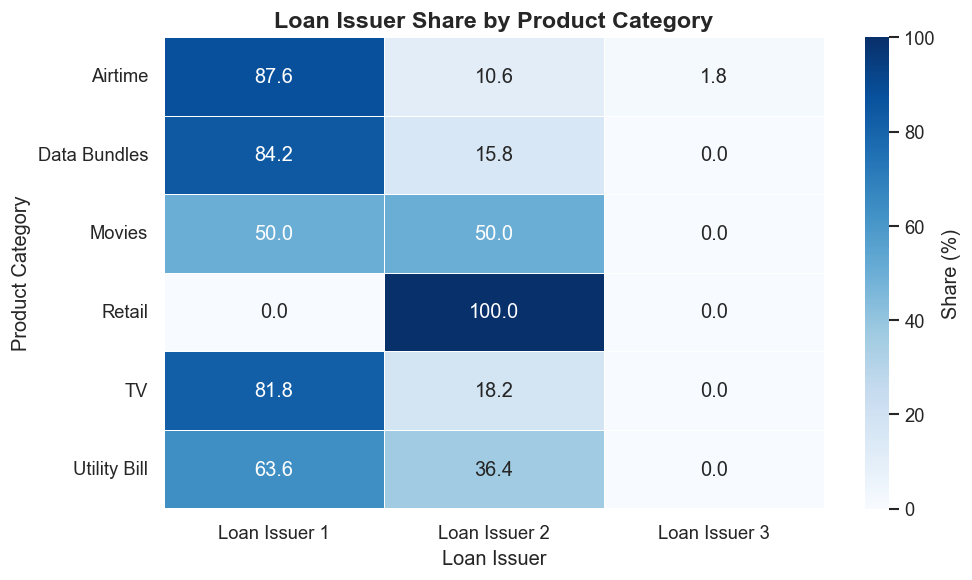

In [6]:
product_issuer_summary = (
    cold_start
    .groupby(["product_category_label", "loan_issuer_label"], observed=False)
    .agg(
        loan_count=("IsDefaulted", "count"),
        default_count=("IsDefaulted", "sum"),
        default_rate=("IsDefaulted", "mean"),
    )
    .reset_index()
)
product_issuer_summary["default_rate_pct"] = product_issuer_summary["default_rate"] * 100
display(product_issuer_summary.rename(columns={
    "product_category_label": "Product Category",
    "loan_issuer_label": "Loan Issuer",
    "loan_count": "Loan Count",
    "default_count": "Default Count",
    "default_rate_pct": "Default Rate (%)",
}))

issuer_share = product_issuer_summary.pivot_table(
    index="product_category_label",
    columns="loan_issuer_label",
    values="loan_count",
    aggfunc="sum",
    fill_value=0,
)
issuer_share = issuer_share.div(issuer_share.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8.5, 5.0))
sns.heatmap(issuer_share, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5, cbar_kws={"label": "Share (%)"}, ax=ax)
ax.set_title("Loan Issuer Share by Product Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Loan Issuer")
ax.set_ylabel("Product Category")
plt.tight_layout()
save_fig("main_04_product_category_x_loan_issuer.png")
plt.show()


## Retail and loan issuer 2 share
### 리테일 및 대출 공급자 2 비중


,Transaction History Group,Loan Count,retail_share,issuer_2_share,Retail Share (%),Loan Issuer 2 Share (%)
0,No prior transaction,217,0.281106,0.387097,28.110599,38.709677
1,Low transaction history,20,0.100000,0.400000,10.000000,40.000000
2,Medium transaction history,64,0.015625,0.187500,1.562500,18.750000
3,High transaction history,84,0.000000,0.083333,0.000000,8.333333


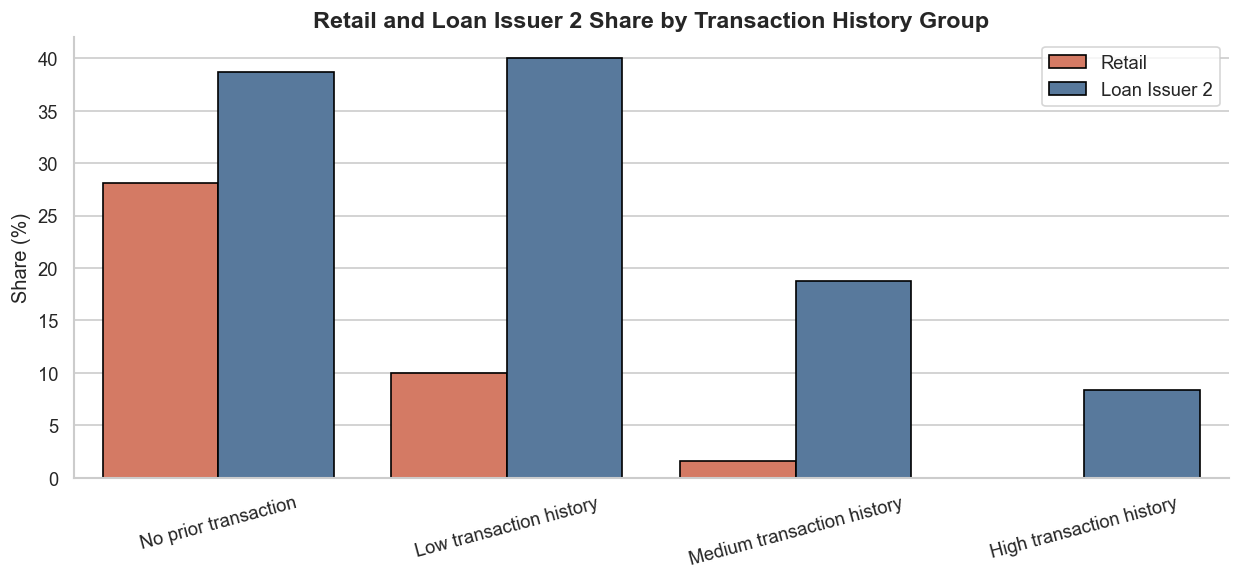

In [7]:
structure_share = (
    cold_start
    .assign(
        is_retail=lambda data: data["product_category_label"].eq("Retail"),
        is_issuer_2=lambda data: data["loan_issuer_label"].eq("Loan Issuer 2"),
    )
    .groupby("transaction_history_group", observed=False)
    .agg(
        loan_count=("IsDefaulted", "count"),
        retail_share=("is_retail", "mean"),
        issuer_2_share=("is_issuer_2", "mean"),
    )
    .reset_index()
)
structure_share["retail_share_pct"] = structure_share["retail_share"] * 100
structure_share["issuer_2_share_pct"] = structure_share["issuer_2_share"] * 100
display(structure_share.rename(columns={
    "transaction_history_group": "Transaction History Group",
    "loan_count": "Loan Count",
    "retail_share_pct": "Retail Share (%)",
    "issuer_2_share_pct": "Loan Issuer 2 Share (%)",
}))

plot_share = structure_share.melt(
    id_vars=["transaction_history_group"],
    value_vars=["retail_share_pct", "issuer_2_share_pct"],
    var_name="structural_factor",
    value_name="share_pct",
)
plot_share["structural_factor"] = plot_share["structural_factor"].map({
    "retail_share_pct": "Retail",
    "issuer_2_share_pct": "Loan Issuer 2",
})

fig, ax = plt.subplots(figsize=(10.5, 5.0))
sns.barplot(
    data=plot_share,
    x="transaction_history_group",
    y="share_pct",
    hue="structural_factor",
    palette={"Retail": retail_color, "Loan Issuer 2": "#4C78A8"},
    edgecolor="black",
    linewidth=1,
    ax=ax,
)
ax.set_title("Retail and Loan Issuer 2 Share by Transaction History Group", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Share (%)")
ax.tick_params(axis="x", rotation=15)
ax.legend(title="")
sns.despine(left=False, bottom=False)
plt.tight_layout()
save_fig("main_05_structural_share_by_transaction_history.png")
plt.show()


## Structural exclusion check
### 구조 변수 제외 확인


,Scenario,Loan Count,Default Count,Default Rate (%)
0,Original,217,53,24.423963
1,Excluding Retail,156,4,2.564103
2,Excluding Loan Issuer 2,133,4,3.007519
3,Excluding Both,133,4,3.007519


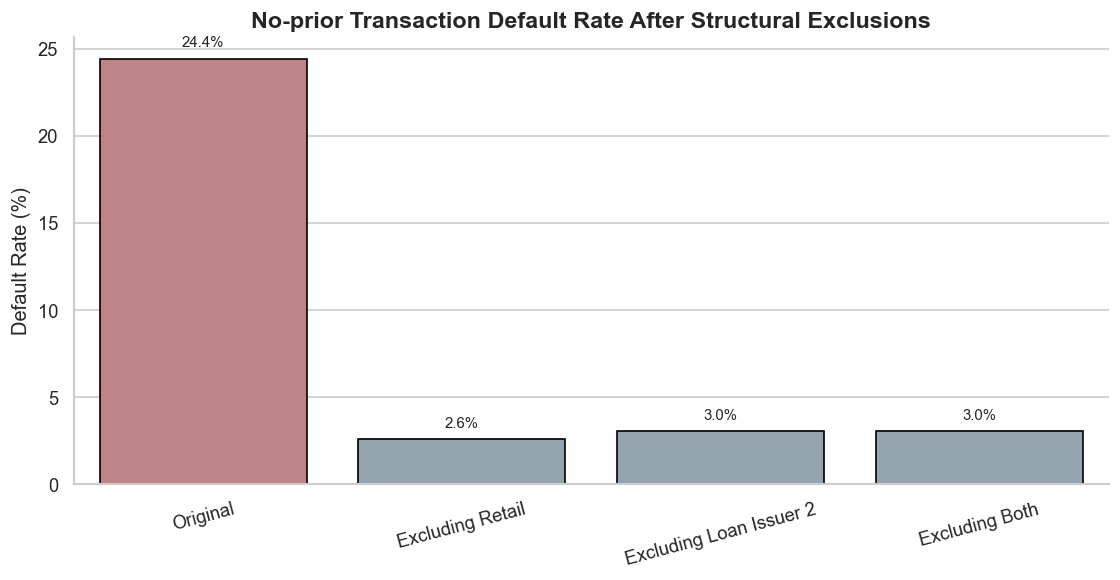

In [8]:
no_history_label = "No prior transaction"
robust_rows = []
scenarios = {
    "Original": cold_start,
    "Excluding Retail": cold_start[cold_start["product_category_label"].ne("Retail")],
    "Excluding Loan Issuer 2": cold_start[cold_start["loan_issuer_label"].ne("Loan Issuer 2")],
    "Excluding Both": cold_start[
        cold_start["product_category_label"].ne("Retail")
        & cold_start["loan_issuer_label"].ne("Loan Issuer 2")
    ],
}

for scenario_name, scenario_data in scenarios.items():
    subset = scenario_data[scenario_data["transaction_history_group"].astype(str).eq(no_history_label)]
    robust_rows.append({
        "scenario": scenario_name,
        "loan_count": len(subset),
        "default_count": int(subset["IsDefaulted"].sum()),
        "default_rate_pct": subset["IsDefaulted"].mean() * 100 if len(subset) else np.nan,
    })

robust_summary = pd.DataFrame(robust_rows)
display(robust_summary.rename(columns={
    "scenario": "Scenario",
    "loan_count": "Loan Count",
    "default_count": "Default Count",
    "default_rate_pct": "Default Rate (%)",
}))

fig, ax = plt.subplots(figsize=(9.5, 5.0))
sns.barplot(
    data=robust_summary,
    x="scenario",
    y="default_rate_pct",
    palette=[highlight_color, neutral_color, neutral_color, neutral_color],
    edgecolor="black",
    linewidth=1,
    ax=ax,
)
ax.set_title("No-prior Transaction Default Rate After Structural Exclusions", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Default Rate (%)")
ax.tick_params(axis="x", rotation=15)
label_bar_patches(ax)
sns.despine(left=False, bottom=False)
plt.tight_layout()
save_fig("main_06_no_prior_txn_structural_exclusion.png")
plt.show()


## Service flow ID
### 서비스 흐름 ID


,Service Flow ID,Loan Count,Default Count,default_rate,Default Rate (%)
4,Service Flow ID 7,270,9,0.033333,3.333333
3,Service Flow ID 6,63,50,0.793651,79.365079
0,Service Flow ID 1,35,0,0.000000,0.000000
2,Service Flow ID 5,13,0,0.000000,0.000000
1,Service Flow ID 4,4,0,0.000000,0.000000


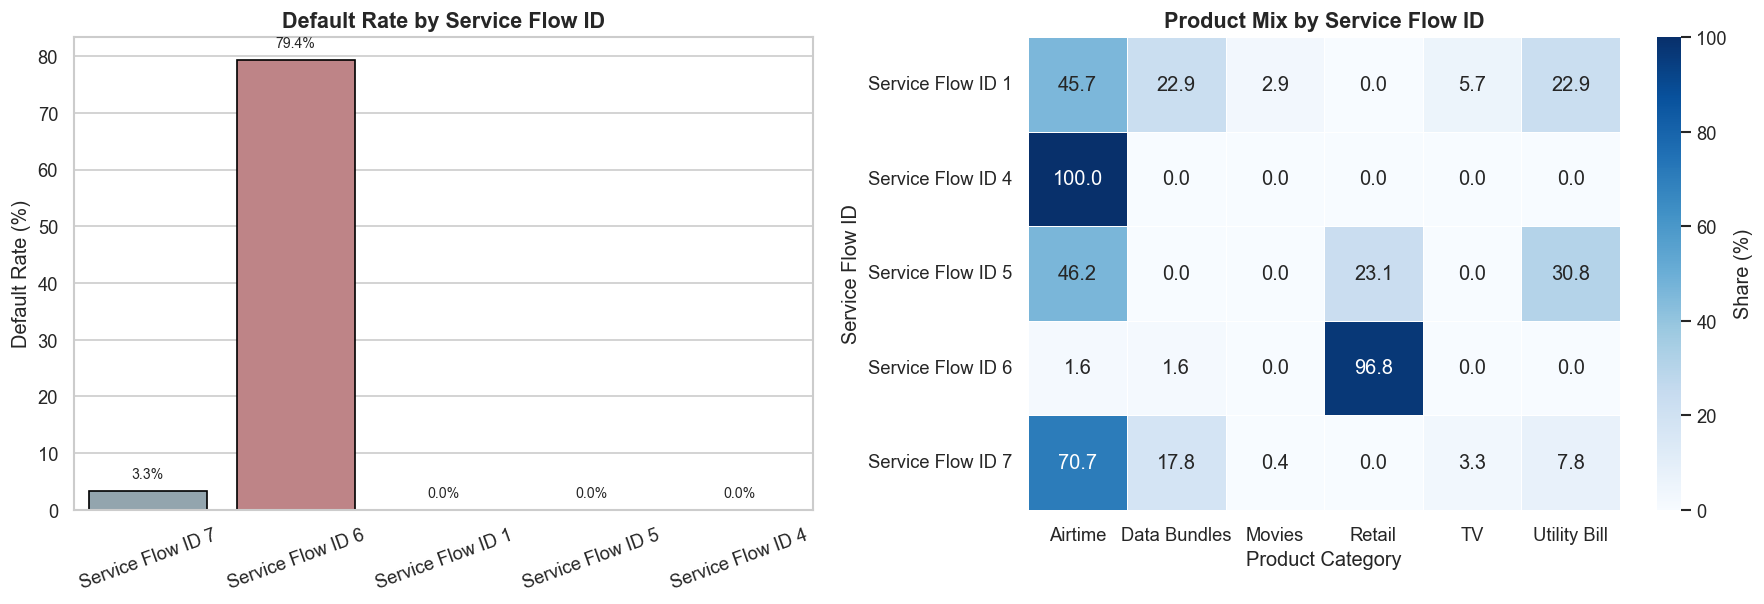

In [9]:
service_flow_summary = default_rate_table(cold_start, "service_flow_label")
service_flow_summary = service_flow_summary.sort_values("loan_count", ascending=False)
display(service_flow_summary.rename(columns={
    "service_flow_label": "Service Flow ID",
    "loan_count": "Loan Count",
    "default_count": "Default Count",
    "default_rate_pct": "Default Rate (%)",
}))

service_product_count = pd.crosstab(
    cold_start["service_flow_label"],
    cold_start["product_category_label"],
)
service_product_share = service_product_count.div(service_product_count.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(15.0, 5.2))
sns.barplot(
    data=service_flow_summary,
    x="service_flow_label",
    y="default_rate_pct",
    palette=[highlight_color if x == "Service Flow ID 6" else neutral_color for x in service_flow_summary["service_flow_label"]],
    edgecolor="black",
    linewidth=1,
    ax=axes[0],
)
axes[0].set_title("Default Rate by Service Flow ID", fontsize=13, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Default Rate (%)")
axes[0].tick_params(axis="x", rotation=20)
label_bar_patches(axes[0], fontsize=8.5)

sns.heatmap(
    service_product_share,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Share (%)"},
    ax=axes[1],
)
axes[1].set_title("Product Mix by Service Flow ID", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Product Category")
axes[1].set_ylabel("Service Flow ID")
plt.tight_layout()
save_fig("main_07_service_flow_default_and_product_mix.png")
plt.show()
